In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/drive/MyDrive/pothole_dataset/data/data.yaml",
    epochs=60,            # increased epochs
    imgsz=1024,            # better small object detection
    batch=8,               # stable for T4 GPU
    patience=15,           # avoid early stopping too soon
    optimizer="AdamW",     # better convergence
    lr0=0.001,             # learning rate
    weight_decay=0.0005,   # reduce overfitting
    cos_lr=True,           # cosine learning rate scheduler
    hsv_h=0.015,           # augmentation
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    flipud=0.2,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    name="pothole_final_model"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/pothole_dataset/data/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f59c807be00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.4 ms, read: 51.7±24.1 MB/s, size: 90.1 KB)
val: Scanning /content/drive/MyDrive/pothole_dataset/data/valid/labels.cache... 260 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 260/260 51.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 1.4it/s 12.2s
                   all        260        573      0.797      0.683      0.763      0.336
Speed: 10.6ms preprocess, 23.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f59f0bda7b0>
curves: ['Precision-Recall(B)',

In [ ]:
from google.colab import files
files.download("/content/runs/detect/pothole_final_model/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/drive/MyDrive/pothole_dataset/data/test/images/12_jpg.rf.98223fbf0c9935d763f81b9e25e9712b.jpg: 1024x1024 1 pothole, 32.1ms
Speed: 7.5ms preprocess, 32.1ms inference, 2.8ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/runs/detect/predict


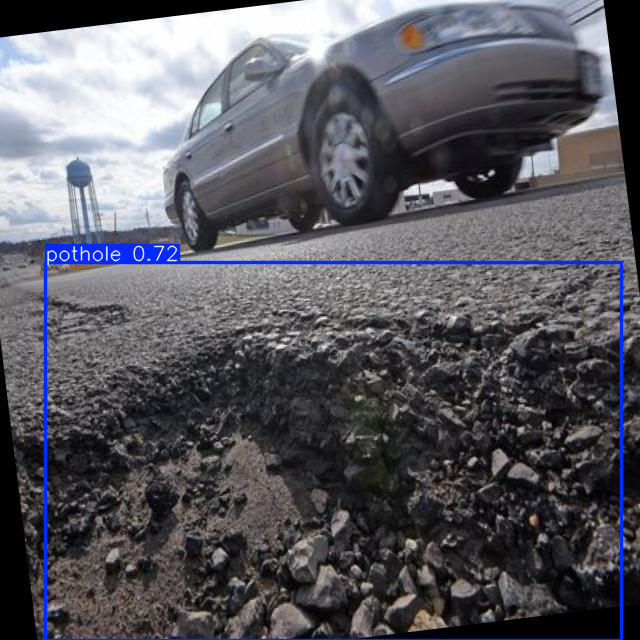

In [ ]:
results = model.predict("/content/drive/MyDrive/pothole_dataset/data/test/images/12_jpg.rf.98223fbf0c9935d763f81b9e25e9712b.jpg", conf=0.25, save=True)
results[0].show()

In [ ]:
import os
from pathlib import Path
from ultralytics import YOLO
import numpy as np

# Helper to read YOLO-format labels (class x_center y_center width height normalized)
def load_labels(label_path, img_width, img_height):
    boxes = []
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, x_c, y_c, w, h = parts
            x_c, y_c, w, h = map(float, (x_c, y_c, w, h))
            # Convert normalized to absolute xyxy box
            x_min = (x_c - w/2) * img_width
            y_min = (y_c - h/2) * img_height
            x_max = (x_c + w/2) * img_width
            y_max = (y_c + h/2) * img_height
            boxes.append([x_min, y_min, x_max, y_max])
    return np.array(boxes)

# IoU calculation
def iou(boxA, boxB):
    # Determine the coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

# Match predicted boxes with ground truth using IoU threshold
def match_boxes(pred_boxes, gt_boxes, iou_threshold=0.5):
    matched_gt = set()
    tp = 0
    fp = 0

    for pred in pred_boxes:
        found_match = False
        for i, gt in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            if iou(pred, gt) >= iou_threshold:
                matched_gt.add(i)
                tp += 1
                found_match = True
                break
        if not found_match:
            fp += 1
    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

# Paths
image_folder = "/content/drive/MyDrive/pothole_dataset/data/test/images"
label_folder = "/content/drive/MyDrive/pothole_dataset/data/test/labels"

# Load model
model = YOLO("/content/runs/detect/pothole_final_model/weights/best.pt")

# Parameters
conf_threshold = 0.2
iou_threshold = 0.5
use_tta = True

# Prepare summary
total_tp, total_fp, total_fn = 0, 0, 0

# Iterate images
for image_path in Path(image_folder).glob("*.jpg"):
    # Load image shape
    from PIL import Image
    img = Image.open(image_path)
    width, height = img.size

    # Load ground truth boxes
    label_path = os.path.join(label_folder, image_path.with_suffix('.txt').name)
    if not os.path.exists(label_path):
        print(f"Label missing for {image_path.name}, skipping")
        continue
    gt_boxes = load_labels(label_path, width, height)

    # Run prediction
    results = model.predict(
        str(image_path),
        conf=conf_threshold,
        iou=0.3,
        augment=use_tta,
        verbose=False,
    )
    pred_boxes = results[0].boxes.xyxy.cpu().numpy() if results[0].boxes else np.array([])

    # Match predictions and ground truth
    tp, fp, fn = match_boxes(pred_boxes, gt_boxes, iou_threshold)
    total_tp += tp
    total_fp += fp
    total_fn += fn

    # Calculate precision, recall for this image
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"{image_path.name}: TP={tp}, FP={fp}, FN={fn}, Precision={precision:.3f}, Recall={recall:.3f}")

# Overall metrics
overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

print("\n==== Summary ====")
print(f"Total True Positives: {total_tp}")
print(f"Total False Positives: {total_fp}")
print(f"Total False Negatives: {total_fn}")
print(f"Overall Precision: {overall_precision:.3f}")
print(f"Overall Recall: {overall_recall:.3f}")

253_jpg.rf.791ecc3c941626c25b69060f9aaf3453.jpg: TP=3, FP=0, FN=0, Precision=1.000, Recall=1.000
139_jpg.rf.f2928d6451a5fd5ef95a3051b4b2ba5a.jpg: TP=6, FP=5, FN=2, Precision=0.545, Recall=0.750
12_jpg.rf.98223fbf0c9935d763f81b9e25e9712b.jpg: TP=1, FP=0, FN=0, Precision=1.000, Recall=1.000
19_jpg.rf.c0972876ad058389d3ec2943deae367d.jpg: TP=8, FP=4, FN=2, Precision=0.667, Recall=0.800
181_jpg.rf.f5d2a9174fcd2f2b3aa547325f9863b0.jpg: TP=2, FP=1, FN=1, Precision=0.667, Recall=0.667
241_jpg.rf.c6304a6a1453821dfd5695de9a938c3a.jpg: TP=5, FP=2, FN=5, Precision=0.714, Recall=0.500
20240621_212348_jpg.rf.ae0a06a2bfa8f47d7f9a50f8c09deda8.jpg: TP=1, FP=1, FN=0, Precision=0.500, Recall=1.000
264_jpg.rf.38d24272cafad71650a8867db81925e3.jpg: TP=5, FP=0, FN=0, Precision=1.000, Recall=1.000
147_jpg.rf.29a0769290af2d4a69db84c5b838eae7.jpg: TP=6, FP=10, FN=2, Precision=0.375, Recall=0.750
15_jpg.rf.efee37dd5a47841089fa6fa96bcded28.jpg: TP=0, FP=1, FN=1, Precision=0.000, Recall=0.000
258_jpg.rf.12e8e535f